# Ultimate comparisons
5s Deep vs 5s handextracted <br>
5s Deep vs 1s Deep <br>
Region Selection starting from 1s vs 3s <br>
Important regions vs Cohen vs All regions <br>
Single modality vs fusion (EEG+MEG) (To be done)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
try:
    del lolliplot
except NameError:
    pass

def lolliplot(he, de, me=None, annotate=None, legendlabels=None):
    """
    takes 3 arrays of performances and plot the performances per subject 
    as a horizontal lollipop plot, SORTED by de
    
    """

    he, de = np.array(he), np.array(de)
    me = np.array(me) if me is not None else None
    ord_ = de.argsort()


    fig, ax = plt.subplots(figsize=(7,5))
    ax.set_yticks(range(len(ord_)))
    ax.set_yticklabels(ord_)

    for y,i in enumerate(ord_):
        xs = [he[i], de[i]] + ([me[i]] if me is not None else [])
        ax.plot([min(xs), max(xs)], [y,y], color="grey", lw=0.8, alpha=0.7)

    ax.scatter(he[ord_], range(len(ord_)), color="red",   alpha=0.8, zorder=10, label=None if legendlabels is None else legendlabels[0])
    ax.scatter(de[ord_], range(len(ord_)), color="green", alpha=0.8, zorder=10, label=None if legendlabels is None else legendlabels[1])
    if me is not None:
        ax.scatter(me[ord_], range(len(ord_)), color="orange", alpha=0.8, zorder=10, label=None if legendlabels is None else legendlabels[2])

    if annotate:
        for y,i in enumerate(ord_):
            if i in annotate:
                if me is None:
                    # original 2-series behavior
                    vals = {"he":he[i], "de":de[i]}
                    sorted_vals = sorted(vals.items(), key=lambda x: x[1])
                    (_, worst),(_, best) = sorted_vals
                    ax.text(worst-0.004, y, f"{worst:.2f}", ha="right", va="center", fontsize=8)
                    ax.text(best+0.005, y, f"{best:.2f}", ha="left",  va="center", fontsize=8)
                else:
                    vals = {"he":he[i], "de":de[i], "me":me[i]}
                    sorted_vals = sorted(vals.items(), key=lambda x: x[1])
                    (_, worst), (_, mid), (_, best) = sorted_vals
                    ax.text(worst-0.004, y, f"{worst:.2f}", ha="right",  va="center", fontsize=8)
                    ax.text(best+0.004,  y, f"{best:.2f}",  ha="left",   va="center", fontsize=8)
                    ax.text(mid, y+0.2, f"{mid:.2f}",     ha="center", va="bottom", fontsize=8)

    lims = ax.get_xlim()
    ax.hlines(range(len(ord_)), lims[0], lims[1], color="grey", lw=0.6, alpha=0.3,
              linestyle=(-10,(40,10)))
    ax.set_xlim(lims[0]-0.01, lims[1]+0.01)

    if legendlabels:
        plt.legend()

    return fig, ax



In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap
def avg_dict(d):
    return float(np.mean(list(d.values())))

# ultimate performances (deep, EEG+MEG, cohen selection from 3s)
acc_mean_deep_region_selection_from_3s = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_from_3s.pkl").Accuracy.apply(np.mean).values)

# region selection from 1s
acc_mean_deep_1s = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN.pkl").Accuracy.apply(np.mean).values)

# region selection from 1s
acc_mean_handextracted_5s = [.97,.75,.91,.75,.83,.97,.86,.81,.85,.88,.93,.82,.9,.75,.89,.77,.88,.76,.76,.78] 

# region selection from 3s
acc_mean_handextracted_5s_region_selection_from_3s = list(pd.read_pickle("../Results/BCI_Performances/All_subjects_BCI_Performances_ultimate_region_selection_from_3s.pkl").Accuracy.apply(np.mean).values)

# Hand - single modality - important regions (basic scenario)
acc_mean_EEG_importatn_regions = pd.read_pickle("../Results/BCI_Performances/All_subjects_BCI_Performances_ultimate_windows_1s_single_modality_EEG_important_rois.pkl")
acc_mean_EEG_importatn_regions["Accuracy"] = acc_mean_EEG_importatn_regions["Accuracy"].apply(lambda lst: [avg_dict(d) for d in lst])
acc_mean_EEG_importatn_regions = list(acc_mean_EEG_importatn_regions.Accuracy.apply(np.mean).values)

acc_mean_MEG_importatn_regions = pd.read_pickle("../Results/BCI_Performances/All_subjects_BCI_Performances_ultimate_windows_1s_single_modality_MEG_important_rois.pkl")
acc_mean_MEG_importatn_regions["Accuracy"] = acc_mean_MEG_importatn_regions["Accuracy"].apply(lambda lst: [avg_dict(d) for d in lst])
acc_mean_MEG_importatn_regions = list(acc_mean_MEG_importatn_regions.Accuracy.apply(np.mean).values)

# region selection from 1s
acc_mean_deep_5s = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_DNN_Classification_5s_windows.pkl").Accuracy.apply(np.mean).values)

# EEG+MEG
acc_mean_deep_all_regions = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_all_regions.pkl").Accuracy.apply(np.mean).values)
acc_mean_deep_important_regions = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_important_regions.pkl").Accuracy.apply(np.mean).values)

# Signle modality classification, region selection (EEG U MEG) from 3s
acc_mean_deep_EEG = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_from_3s_EEG.pkl").Accuracy.apply(np.mean).values)
acc_mean_deep_MEG = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_from_3s_MEG.pkl").Accuracy.apply(np.mean).values)


# Confronto 1: Deep EEG (MEG) cohen single modality vs important
acc_deep_EEG_important_regions = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_EEG_Important_regions.pkl").Accuracy.apply(np.mean).values)
acc_deep_MEG_important_regions = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_MEG_Important_regions.pkl").Accuracy.apply(np.mean).values)

acc_deep_EEG_Only_EEG_selected_regions = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_from_3s_EEG_only_EEG_reg_selection.pkl").Accuracy.apply(np.mean).values)
acc_deep_MEG_Only_MEG_selected_regions = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_from_3s_MEG_only_MEG_reg_selection.pkl").Accuracy.apply(np.mean).values)

# Lemma (Forse) Confronto 2 EEG vs MEG (cohen single modality? regioni differenti...)
# Confronto 2 EEG+MEG cohen (single modality?) vs EEG (MEG)
acc_deep_EEG_MEG_selection_only_EEG = list(pd.read_pickle("../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_from_3s_EEG+MEG_only_EEG_reg_selection.pkl").Accuracy.apply(np.mean).values)

# Confronto 3 Deep EEG+MEG vs PowerSpectra EEG+MEG
acc_mean_deep_region_selection_from_3s, # uu,acc_mean_handextracted_1s_region_selection_from_3s


# ultimate handextracted (PowerSpectra, EEG+MEG, cohen selection from 3s)
uu = pd.read_pickle("../Results/BCI_Performances/All_subjects_BCI_Performances_ultimate_region_selection_from_3s_windows_1s.pkl").Accuracy
conta = 0
acc_mean_handextracted_1s_region_selection_from_3s = []
for acc_subj in uu:
    acc_mean_handextracted_1s_region_selection_from_3s.append(0)
    for fold in acc_subj:
        for wind in range(7):
            conta +=1
            acc_mean_handextracted_1s_region_selection_from_3s[-1] += fold[f"win_{wind}"]/35

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
from scipy import stats
try:
    del lollipop_with_kde
except:
    pass
def lollipop_with_kde(he, de, me=None, annotate=None, legendlabels=None, showdensity=True, sort=True, fontsize=10, colors=["red", "green", "orange"], xaxlims=(0.5,0.9)):
    """
    Lollipop plot + distribution (KDE) strip on top (same x-axis).

    he, de, me: arrays of performances
    annotate: list of subject indices to annotate
    legendlabels: list like ["HE", "DE", "ME"]
    """

    he, de = np.array(he), np.array(de)
    me = np.array(me) if me is not None else None

    ord_ = de.argsort() if sort else np.arange(len(de))

    fig, ax = plt.subplots(figsize=(7,5))

    # =========================
    # LOLLIPOP
    # =========================
    ax.set_yticks(range(len(ord_)))
    ax.set_yticklabels(ord_+1)

    for y, i in enumerate(ord_):
        xs = [he[i], de[i]] + ([me[i]] if me is not None else [])
        ax.plot([min(xs), max(xs)], [y, y], color="grey", lw=0.8, alpha=0.7)

    ax.scatter(he[ord_], range(len(ord_)), color=colors[0],   alpha=0.8,
               zorder=10, label=None if legendlabels is None else legendlabels[0])
    ax.scatter(de[ord_], range(len(ord_)), color=colors[1], alpha=0.8,
               zorder=10, label=None if legendlabels is None else legendlabels[1])

    if me is not None:
        ax.scatter(me[ord_], range(len(ord_)), color=colors[2], alpha=0.8,
                   zorder=10, label=None if legendlabels is None else legendlabels[2])

    # annotations (unchanged)
    if annotate:
        for y, i in enumerate(ord_):
            if i in annotate:
                vals = {"he":he[i], "de":de[i]}
                if me is not None:
                    vals["me"] = me[i]

                sorted_vals = sorted(vals.items(), key=lambda x: x[1])

                if me is None:
                    (_, worst), (_, best) = sorted_vals
                    ax.text(worst-0.004, y, f"{worst:.2f}", ha="right", va="center")
                    ax.text(best+0.005, y, f"{best:.2f}", ha="left",  va="center")
                else:
                    (_, worst), (_, mid), (_, best) = sorted_vals
                    ax.text(worst-0.004, y, f"{worst:.2f}", ha="right", va="center")
                    ax.text(best+0.004,  y, f"{best:.2f}",  ha="left",  va="center")
                    ax.text(mid, y+0.2, f"{mid:.2f}", ha="center", va="bottom")

    ax.set_xlim(xaxlims)
    lims = ax.get_xlim()
    ax.hlines(range(len(ord_)), lims[0], lims[1],
              color="grey", lw=0.6, alpha=0.3,
              linestyle=(-10,(40,10)))
    ax.set_xlim(lims[0]-0.01, lims[1]+0.01)

    if legendlabels:
        ax.legend(fontsize=fontsize)

    ax.tick_params(axis='both', labelsize=fontsize)
    
    ax.set_xlabel("Accuracy",fontsize=fontsize+5,labelpad=fontsize)
    ax.set_ylabel("Subjects",fontsize=fontsize+5,labelpad=fontsize)

    

    # =========================
    # TOP DISTRIBUTION (KDE)
    # =========================
    if showdensity:
        ax_top = inset_axes(
            ax,
            width="100%",
            height="100%",
            loc="upper center",
            bbox_to_anchor=(0, 1, 1, 0.2),
            bbox_transform=ax.transAxes,
            borderpad=0
        )

        data = [he, de] + ([me] if me is not None else [])
        colors = colors[:len(data)]

        for arr, c in zip(data, colors):
            sns.kdeplot(
                arr,
                ax=ax_top,
                color=c,
                fill=True,
                alpha=0.25,
                linewidth=1
            )
            ax_top.axvline(np.mean(arr), color=c, linestyle="--", linewidth=1.2)
            ax_top.axvline(np.median(arr), color=c, linestyle="-", linewidth=1.2)

        # align with main axis
        ax_top.set_xlim(ax.get_xlim())
        ax_top.set_xticks([])
        ax_top.set_yticks([])

        # clean look
        for spine in ax_top.spines.values():
            spine.set_visible(False)
        ax_top.set_ylabel("Density", fontsize=fontsize)

    # plt.tight_layout()
    return fig, ax

## Confronto 1 - EEG(MEG) important vs cohen single modality

	Important 	 Cohen
Mean:   0.6358  	0.6820
Median: 0.6217  	0.6760


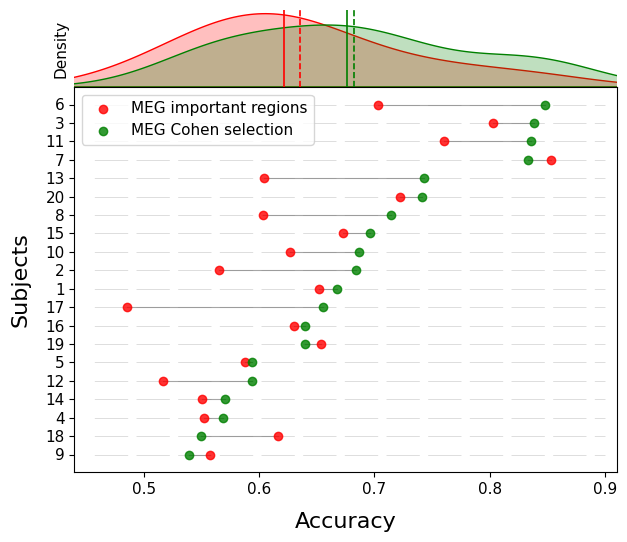

In [91]:
# fig, ax = lollipop_with_kde(acc_deep_EEG_important_regions, acc_deep_EEG_Only_EEG_selected_regions,  legendlabels=["EEG important regions", "EEG Cohen selection"],fontsize=11)
# plt.savefig("../Images/Paper/Lollipop_EEG_cohen_vs_important.png", dpi=300, bbox_inches='tight')
# print("\tImportant \t Cohen")
# print(f"Mean:   {np.mean(acc_deep_EEG_important_regions):.4f}  \t{np.mean(acc_deep_EEG_Only_EEG_selected_regions):.4f}")
# print(f"Median: {np.median(acc_deep_EEG_important_regions):.4f}  \t{np.median(acc_deep_EEG_Only_EEG_selected_regions):.4f}")


fig, ax = lollipop_with_kde(acc_deep_MEG_important_regions, acc_deep_MEG_Only_MEG_selected_regions,  legendlabels=["MEG important regions", "MEG Cohen selection"],fontsize=11, xaxlims=(0.45,0.9))
plt.savefig("../Images/Paper/Lollipop_MEG_cohen_vs_important.png", dpi=300, bbox_inches='tight')
print("\tImportant \t Cohen")
print(f"Mean:   {np.mean(acc_deep_MEG_important_regions):.4f}  \t{np.mean(acc_deep_MEG_Only_MEG_selected_regions):.4f}")
print(f"Median: {np.median(acc_deep_MEG_important_regions):.4f}  \t{np.median(acc_deep_MEG_Only_MEG_selected_regions):.4f}")


In [ ]:
stat, p_value = stats.wilcoxon(acc_deep_EEG_important_regions, acc_deep_EEG_Only_EEG_selected_regions, alternative="two-sided", zero_method="wilcox")
print(f"Test EEG cohen different from EEG important: stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_deep_EEG_important_regions)-np.mean(acc_deep_EEG_Only_EEG_selected_regions):.4f}")

stat, p_value = stats.wilcoxon(acc_deep_MEG_important_regions, acc_deep_MEG_Only_MEG_selected_regions, alternative="two-sided", zero_method="wilcox")
print(f"Test MEG cohen different from MEG important: stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_deep_MEG_important_regions)-np.mean(acc_deep_MEG_Only_MEG_selected_regions):.4f}")

Test EEG cohen different from EEG important: stat=56.0000, p=0.0696, mean difference=-0.0350
Test MEG cohen different from MEG important: stat=31.0000, p=0.0042, mean difference=-0.0462


## Confronto 2 - EEG(MEG) vs EEG+MEG (cohen 1 modality or cohen 2 modality?)

### Confronto 2 - Lemma EEG vs MEG (1 or 2 modality selection?)
Risalto, per alcuni subject MEG è meglio di EEG (debole) <br> 
Altri è confrontabile, potrebbero avere info complementari <br>
forse conviene fare con selection su single modality, e mostrare di confronto anche le double modality <br>
poi presentare direttamente EEG U MEG per confronto EEG vs EEG+MEG <br>
Prova a vedere test statistici su single subjects

Test EEG different MEG (Cohen single): stat=42.0000, p=0.0172, mean difference=-0.0618
MEG:0.6820 EEG: 0.7438
Where MEG > EEG (array([ 2,  5,  6,  7, 10, 12, 18, 19]),)
	MEG 	 EEG
Mean:   0.6820  	0.7438
Median: 0.6760  	0.7543


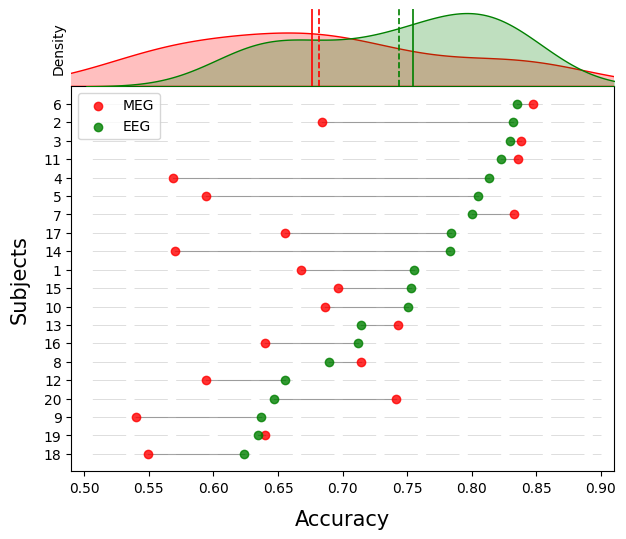

In [6]:
lollipop_with_kde(acc_deep_MEG_Only_MEG_selected_regions, acc_deep_EEG_Only_EEG_selected_regions,  legendlabels=["MEG", "EEG"])
stat, p_value = stats.wilcoxon(acc_deep_MEG_Only_MEG_selected_regions, acc_deep_EEG_Only_EEG_selected_regions, alternative="two-sided", zero_method="wilcox")
print(f"Test EEG different MEG (Cohen single): stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_deep_MEG_Only_MEG_selected_regions)-np.mean(acc_deep_EEG_Only_EEG_selected_regions):.4f}")
print(f"MEG:{np.mean(acc_deep_MEG_Only_MEG_selected_regions):.4f} EEG: {np.mean(acc_deep_EEG_Only_EEG_selected_regions):.4f}")
print(f"Where MEG > EEG {np.where(np.array(acc_deep_MEG_Only_MEG_selected_regions) > np.array(acc_deep_EEG_Only_EEG_selected_regions))}")
plt.savefig("../Images/Paper/Lollipop_EEG_vs_MEG_cohen_single_modality.png", dpi=300, bbox_inches='tight')

print("\tMEG \t EEG")
print(f"Mean:   {np.mean(acc_deep_MEG_Only_MEG_selected_regions):.4f}  \t{np.mean(acc_deep_EEG_Only_EEG_selected_regions):.4f}")
print(f"Median: {np.median(acc_deep_MEG_Only_MEG_selected_regions):.4f}  \t{np.median(acc_deep_EEG_Only_EEG_selected_regions):.4f}")


Test EEG different MEG (Cohen EEG U MEG): stat=26.0000, p=0.0020, mean difference=-0.0800
MEG:0.6878 EEG: 0.7678
Where MEG > EEG (array([ 2,  5,  6, 12, 19]),)
	MEG 		 EEG
Mean:   0.6878  	0.7678
Median: 0.6801  	0.7651


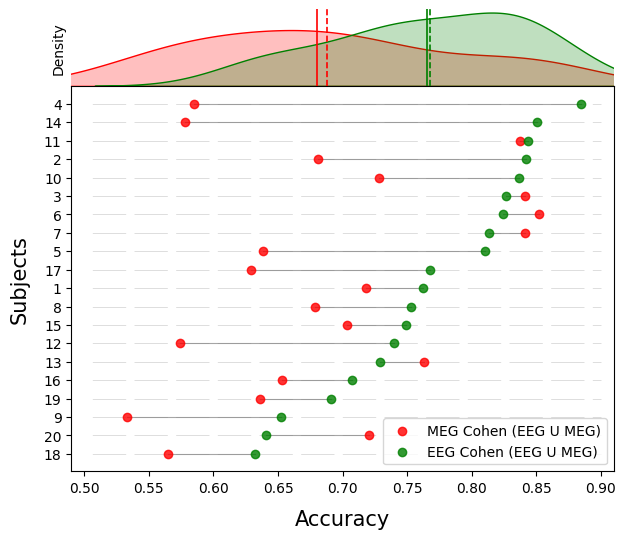

In [ ]:
lollipop_with_kde(acc_mean_deep_MEG, acc_mean_deep_EEG,  legendlabels=["MEG Cohen (EEG U MEG)", "EEG Cohen (EEG U MEG)"])
stat, p_value = stats.wilcoxon(acc_mean_deep_MEG, acc_mean_deep_EEG, alternative="two-sided", zero_method="wilcox")
print(f"Test EEG different MEG (Cohen EEG U MEG): stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_mean_deep_MEG)-np.mean(acc_mean_deep_EEG):.4f}")
print(f"MEG:{np.mean(acc_mean_deep_MEG):.4f} EEG: {np.mean(acc_mean_deep_EEG):.4f}")
print(f"Where MEG > EEG {np.where(np.array(acc_mean_deep_MEG) > np.array(acc_mean_deep_EEG))}")
plt.savefig("../Images/Paper/Lollipop_EEG_vs_MEG_cohen_EEG_U_MEG.png", dpi=300, bbox_inches='tight')
print("\tMEG \t\t EEG")
print(f"Mean:   {np.mean(acc_mean_deep_MEG):.4f}  \t{np.mean(acc_mean_deep_EEG):.4f}")
print(f"Median: {np.median(acc_mean_deep_MEG):.4f}  \t{np.median(acc_mean_deep_EEG):.4f}")

### Confronto 2 EEG(MEG) vs EEG+MEG

Test EEG+MEG different EEG (Cohen multiple): stat=3.0000, p=0.0000, mean difference=-0.0918
MEG:0.6878 EEG+MEG: 0.7797


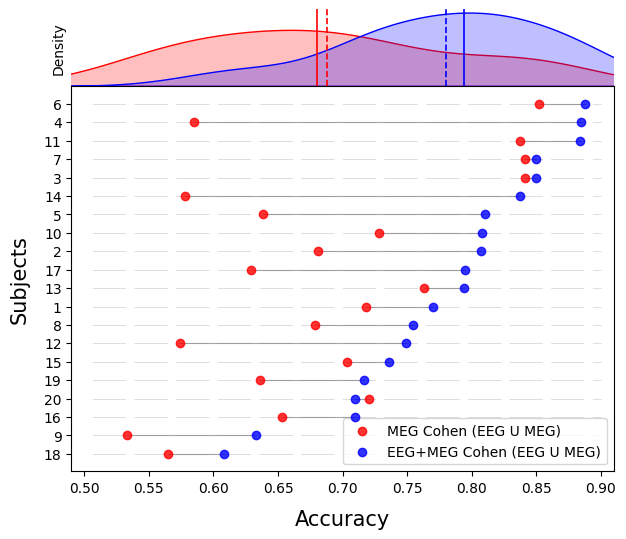

In [ ]:
# Region Selection Cohen EEG U MEG

fig,ax = lollipop_with_kde(acc_mean_deep_MEG, acc_mean_deep_region_selection_from_3s,  legendlabels=["MEG Cohen (EEG U MEG)", "EEG+MEG Cohen (EEG U MEG)"], colors=["red", "blue"])
stat, p_value = stats.wilcoxon(acc_mean_deep_MEG, acc_mean_deep_region_selection_from_3s, alternative="two-sided", zero_method="wilcox")
print(f"Test EEG+MEG different EEG (Cohen multiple): stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_mean_deep_MEG)-np.mean(acc_mean_deep_region_selection_from_3s):.4f}")
print(f"MEG:{np.mean(acc_mean_deep_MEG):.4f} EEG+MEG: {np.mean(acc_mean_deep_region_selection_from_3s):.4f}")
plt.savefig("../Images/Paper/Lollipop_EEGMEG_vs_MEG_cohen_EEG_U_MEG.png", dpi=300, bbox_inches='tight')


# fig,ax = lollipop_with_kde(acc_mean_deep_EEG, acc_mean_deep_region_selection_from_3s,  legendlabels=["EEG Cohen (EEG U MEG)", "EEG+MEG Cohen (EEG U MEG)"], colors=["green", "blue"])
# stat, p_value = stats.wilcoxon(acc_mean_deep_EEG, acc_mean_deep_region_selection_from_3s, alternative="two-sided", zero_method="wilcox")
# print(f"Test EEG+MEG different EEG (Cohen multiple): stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_mean_deep_EEG)-np.mean(acc_mean_deep_region_selection_from_3s):.4f}")
# print(f"EEG:{np.mean(acc_mean_deep_EEG):.4f} EEG+MEG: {np.mean(acc_mean_deep_region_selection_from_3s):.4f}")
# plt.savefig("../Images/Paper/Lollipop_EEGMEG_vs_EEG_cohen_EEG_U_MEG.png", dpi=300, bbox_inches='tight')

# print("\tEEG \t\t EEG+MEG")
# print(f"Mean:   {np.mean(acc_mean_deep_EEG):.4f}  \t{np.mean(acc_mean_deep_region_selection_from_3s):.4f}")
# print(f"Median: {np.median(acc_mean_deep_EEG):.4f}  \t{np.median(acc_mean_deep_region_selection_from_3s):.4f}")

Test EEG+MEG different EEG (Cohen only EEG): stat=90.0000, p=0.5958, mean difference=-0.0056
EEG:0.7438 EEG+MEG: 0.7494


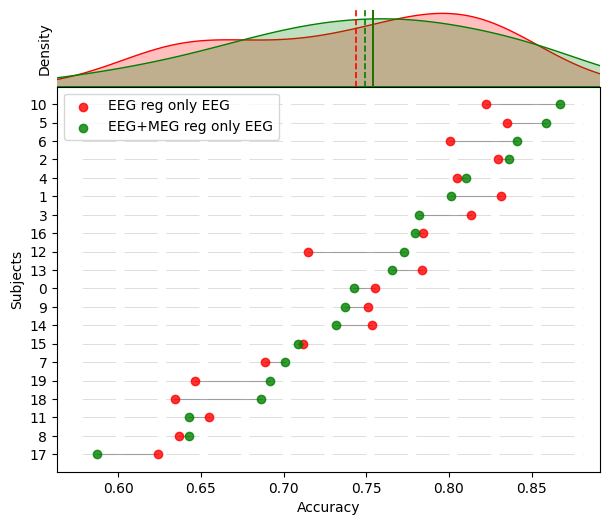

In [ ]:
# Region Selection Cohen only EEG  (DA NON MOSTRARE)

fig,ax = lollipop_with_kde(acc_deep_EEG_Only_EEG_selected_regions, acc_deep_EEG_MEG_selection_only_EEG,  legendlabels=["EEG reg only EEG", "EEG+MEG reg only EEG"], colors=["green", "blue"])
stat, p_value = stats.wilcoxon(acc_deep_EEG_Only_EEG_selected_regions, acc_deep_EEG_MEG_selection_only_EEG, alternative="two-sided", zero_method="wilcox")
print(f"Test EEG+MEG different EEG (Cohen only EEG): stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_deep_EEG_Only_EEG_selected_regions)-np.mean(acc_deep_EEG_MEG_selection_only_EEG):.4f}")
print(f"EEG:{np.mean(acc_deep_EEG_Only_EEG_selected_regions):.4f} EEG+MEG: {np.mean(acc_deep_EEG_MEG_selection_only_EEG):.4f}")

### Confronto 2 EEG+MEG vs best between EEG,MEG

Test best between EEG and MEG different from EEG+MEG: stat=75.0000, p=0.6475
	best EEG MEG 	EEG+MEG
Mean:   0.7770  	0.7797
Median: 0.7653  	0.7942


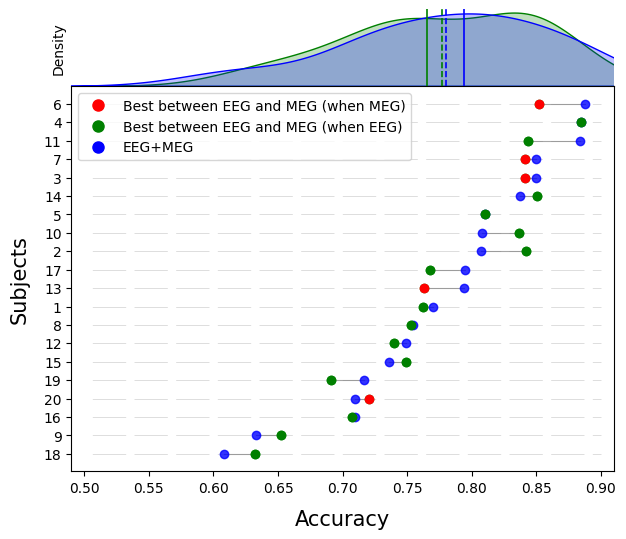

In [101]:

import matplotlib.lines as mlines

acc_mean_best_between_EEG_MEG = np.maximum(acc_mean_deep_EEG, acc_mean_deep_MEG)

fig,ax = lollipop_with_kde(acc_mean_best_between_EEG_MEG, acc_mean_deep_region_selection_from_3s, colors=["green","blue"])

ordine_EEEGplusMEG = np.argsort(acc_mean_deep_region_selection_from_3s)

best_MEG = []
best_EEG = []
for i in range(len(acc_mean_deep_MEG)):
    if acc_mean_deep_MEG[i] > acc_mean_deep_EEG[i]:
        best_MEG.append((acc_mean_deep_MEG[i],np.where(ordine_EEEGplusMEG==i)[0][0]))

for i in range(len(acc_mean_deep_EEG)):
    if acc_mean_deep_EEG[i] >= acc_mean_deep_MEG[i]:
        best_EEG.append((acc_mean_deep_EEG[i],np.where(ordine_EEEGplusMEG==i)[0][0]))

ax.scatter([i[0] for i in best_EEG], [i[1] for i in best_EEG], zorder=20,color="green")
ax.scatter([i[0] for i in best_MEG], [i[1] for i in best_MEG], zorder=20,color="red")

red_dot = mlines.Line2D([], [], color='red', marker='o', linestyle='None',
                        markersize=8, label='Best between EEG and MEG (when MEG)')
green_dot = mlines.Line2D([], [], color='green', marker='o', linestyle='None',
                        markersize=8, label='Best between EEG and MEG (when EEG)'
                        )
blue_dot = mlines.Line2D([], [], color='blue', marker='o', linestyle='None',
                        markersize=8, label='EEG+MEG'
                        )
ax.legend(handles=[red_dot, green_dot, blue_dot])
stat, p_value = stats.wilcoxon(acc_mean_best_between_EEG_MEG, acc_mean_deep_region_selection_from_3s, alternative="two-sided", zero_method="wilcox")
print(f"Test best between EEG and MEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")
plt.savefig("../Images/Paper/Lollipop_EEGMEG_vs_best_EEG_MEG_cohen_EEG_U_MEG.png", dpi=300, bbox_inches='tight')

print("\tbest EEG MEG \tEEG+MEG")
print(f"Mean:   {np.mean(acc_mean_best_between_EEG_MEG):.4f}  \t{np.mean(acc_mean_deep_region_selection_from_3s):.4f}")
print(f"Median: {np.median(acc_mean_best_between_EEG_MEG):.4f}  \t{np.median(acc_mean_deep_region_selection_from_3s):.4f}")

In [ ]:
from scipy.stats import wasserstein_distance

from scipy.stats import ks_2samp
ks_2samp(acc_mean_best_between_EEG_MEG, acc_mean_deep_region_selection_from_3s)
# statistica 0.15 è uguale a statistica di distribuzione uniforme [0,1] e [0.15,1]

0.014378599685488222


KstestResult(statistic=np.float64(0.15), pvalue=np.float64(0.9831368772656193), statistic_location=np.float64(0.7676470588235293), statistic_sign=np.int8(1))

<Axes: ylabel='Density'>

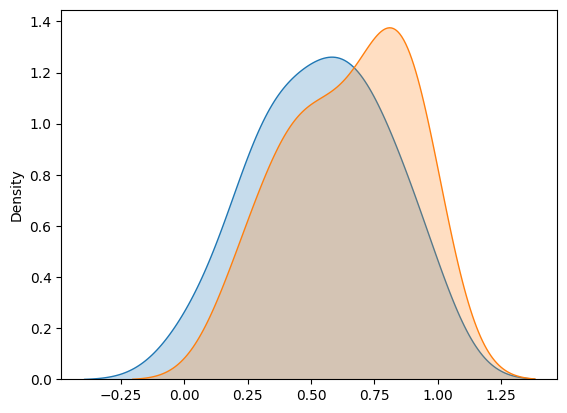

In [170]:
u1=np.random.uniform(0,1,20)
u2=np.random.uniform(0.15,1,20)
sns.kdeplot(u1,fill=True,alpha=0.25,linewidth=1)
sns.kdeplot(u2,fill=True,alpha=0.25,linewidth=1)

In [171]:
ks_2samp(u1,u2)

KstestResult(statistic=np.float64(0.25), pvalue=np.float64(0.571336004933722), statistic_location=np.float64(0.7399675931427356), statistic_sign=np.int8(1))

In [107]:
stats.wilcoxon(u1, u2, alternative="two-sided", zero_method="wilcox")

WilcoxonResult(statistic=np.float64(240446.0), pvalue=np.float64(0.2831950514540382))

## Confronto 3 - EEG+MEG - Deep vs HandExtracted

Test Deep different from HandExtracted: stat=1.0000, p=0.0000, mean difference=-0.0412
	Hand Extracted 	Deep
Mean:   0.7384  	0.7797
Median: 0.7339  	0.7942


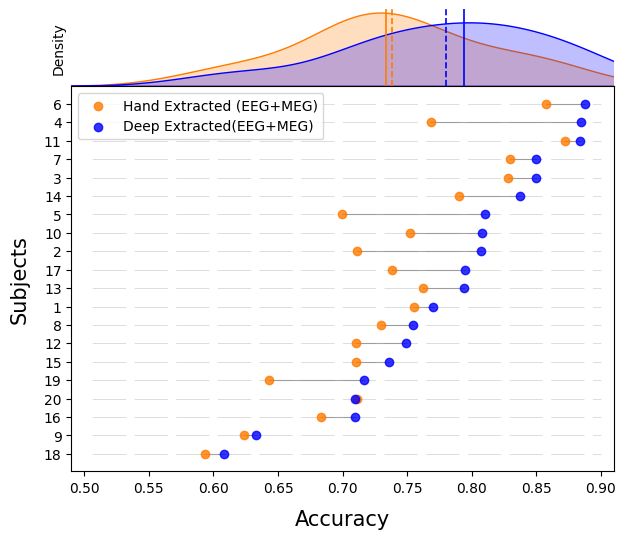

In [102]:
acc_mean_deep_region_selection_from_3s
acc_mean_handextracted_1s_region_selection_from_3s

lollipop_with_kde(acc_mean_handextracted_1s_region_selection_from_3s, acc_mean_deep_region_selection_from_3s,  legendlabels=["Hand Extracted (EEG+MEG)", "Deep Extracted(EEG+MEG)"], colors=["#FF7B00", "blue"])
stat, p_value = stats.wilcoxon(acc_mean_handextracted_1s_region_selection_from_3s, acc_mean_deep_region_selection_from_3s, alternative="two-sided", zero_method="wilcox")
print(f"Test Deep different from HandExtracted: stat={stat:.4f}, p={p_value:.4f}, mean difference={np.mean(acc_mean_handextracted_1s_region_selection_from_3s)-np.mean(acc_mean_deep_region_selection_from_3s):.4f}")
plt.savefig("../Images/Paper/Lollipop_EEGMEG_Deep_vs_HandExtracted.png", dpi=300, bbox_inches='tight')

print("\tHand Extracted \tDeep")
print(f"Mean:   {np.mean(acc_mean_handextracted_1s_region_selection_from_3s):.4f}  \t{np.mean(acc_mean_deep_region_selection_from_3s):.4f}")
print(f"Median: {np.median(acc_mean_handextracted_1s_region_selection_from_3s):.4f}  \t{np.median(acc_mean_deep_region_selection_from_3s):.4f}")

### Test statistici - verifica differenze significative tra diversi addestramenti

In [ ]:
from scipy import stats
import numpy as np
stat, p_value = stats.wilcoxon(acc_mean_deep_MEG, acc_mean_deep_EEG, alternative="two-sided", zero_method="wilcox")
print(f"Test MEG different from EEG: stat={stat:.4f}, p={p_value:.4f}")

stat, p_value = stats.wilcoxon(acc_mean_deep_MEG, acc_mean_deep_region_selection_from_3s, alternative="two-sided", zero_method="wilcox")
print(f"Test MEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")

stat, p_value = stats.wilcoxon(acc_mean_deep_EEG, acc_mean_deep_region_selection_from_3s, alternative="two-sided", zero_method="wilcox")
print(f"Test EEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")

acc_mean_best_between_EEG_MEG = np.maximum(acc_mean_deep_EEG, acc_mean_deep_MEG)

stat, p_value = stats.wilcoxon(acc_mean_best_between_EEG_MEG, acc_mean_deep_region_selection_from_3s, alternative="two-sided", zero_method="wilcox")
print(f"Test best between EEG and MEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")





Test MEG different from EEG: stat=26.0000, p=0.0020
Test MEG different from EEG+MEG: stat=3.0000, p=0.0000
Test EEG different from EEG+MEG: stat=52.0000, p=0.1446
Test best between EEG and MEG different from EEG+MEG: stat=75.0000, p=0.6475


In [ ]:
# Shapiro-Wilk - verifico se è possibile fare t-test o meno
# null hypotesis gaussian distribution
acc_mean_deep_MEG = np.array(acc_mean_deep_MEG)
acc_mean_deep_EEG = np.array(acc_mean_deep_EEG)
acc_mean_deep_region_selection_from_3s = np.array(acc_mean_deep_region_selection_from_3s)

stat, p_value = stats.shapiro(acc_mean_deep_MEG - acc_mean_deep_EEG)
print(f"Test MEG different from EEG: stat={stat:.4f}, p={p_value:.4f}")

stat, p_value = stats.shapiro(acc_mean_deep_MEG- acc_mean_deep_region_selection_from_3s)
print(f"Test MEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")

stat, p_value = stats.shapiro(acc_mean_deep_EEG- acc_mean_deep_region_selection_from_3s)
print(f"Test EEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")

acc_mean_best_between_EEG_MEG = np.maximum(acc_mean_deep_EEG, acc_mean_deep_MEG)

stat, p_value = stats.shapiro(acc_mean_best_between_EEG_MEG- acc_mean_deep_region_selection_from_3s)
print(f"Test best between EEG and MEG different from EEG+MEG: stat={stat:.4f}, p={p_value:.4f}")

Test MEG different from EEG: stat=0.9549, p=0.4484
Test MEG different from EEG+MEG: stat=0.8824, p=0.0195
Test EEG different from EEG+MEG: stat=0.9455, p=0.3034
Test best between EEG and MEG different from EEG+MEG: stat=0.9661, p=0.6713


# Giustifica che scegliamo 8 regioni: Performance Vs number of region selected (EEG+MEG)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

nomebase = "../Results/BCI_Performances/DNN/All_subjects_BCI_Performances_ultimate_DNN_region_selection_"
frm = "from_3s"
nregions = [4, 8, 12, 16, 20, 32, 68]
suffix = [f"_{u}regions.pkl" for u in nregions]
suffix[1] = ".pkl"


tutte_performance_dataframes = [nomebase + frm + s for s in suffix]
tutte_performance_dataframes[-1] = nomebase + "all_regions.pkl"

tutte_performance = []
for pat in tutte_performance_dataframes:
    # performance of each subject of each case
    tutte_performance.append(list(pd.read_pickle(pat).Accuracy.apply(np.mean).values))

tutte_performance = np.array(tutte_performance)

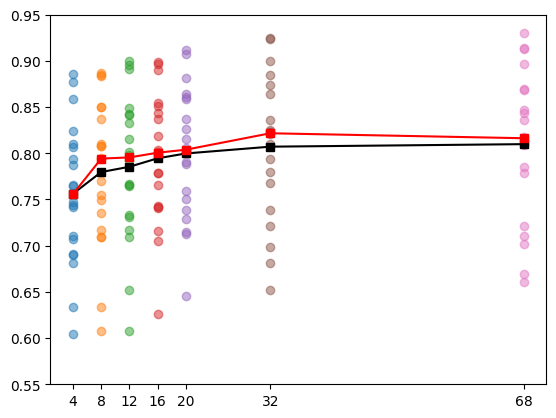

In [ ]:

plt.plot(nregions, tutte_performance.mean(axis=1), marker = "s", color="black", label="Mean")
plt.plot(nregions, np.median(tutte_performance,axis=1), marker = "s", color="red", label="Median")
plt.ylim((0.55,0.95))
plt.xticks(nregions)
for i in range(len(nregions)):
    plt.scatter([nregions[i] for _ in range(len(tutte_performance[i]))], tutte_performance[i], zorder=-1, alpha =0.5)

In [ ]:
for i in np.diff(tutte_performance.mean(axis=1)):
    print(f"{i:.3f}")

0.023
0.006
0.009
0.005
0.007
0.003


In [ ]:
tutte_performance.mean(axis=1)

array([0.75623298, 0.77967653, 0.78539054, 0.79452957, 0.79978925,
       0.80715118, 0.80988114])

### Test statistici - verifica differenze significative tra diversi addestramenti

Shapiro-Wilk uno tra i più usati per fare test di normalità di distribuzioni

In [ ]:
from scipy import stats
# Shapiro-Wilk - verifico se è possibile fare t-test o meno
# sembra conveniente non fare t-test (non c'è gaussianità)

for i in range(len(tutte_performance)):
    for j in range(i+1, len(tutte_performance)):
        differences = tutte_performance[i] - tutte_performance[j]  
        shapiro_stat, shapiro_p = stats.shapiro(differences)
        print(f"Shapiro-Wilk (test for normality) {i}, {j}: stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")
print("Test normalità singole distribuzioni:")
for i in range(len(tutte_performance)):
    shapiro_stat, shapiro_p = stats.shapiro(tutte_performance[i])
    print(f"Shapiro-Wilk (test for normality) {i}, stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")

Shapiro-Wilk (test for normality) 0, 1: stat=0.7239, p=0.0001
Shapiro-Wilk (test for normality) 0, 2: stat=0.7401, p=0.0001
Shapiro-Wilk (test for normality) 0, 3: stat=0.7605, p=0.0002
Shapiro-Wilk (test for normality) 0, 4: stat=0.8233, p=0.0020
Shapiro-Wilk (test for normality) 0, 5: stat=0.8741, p=0.0139
Shapiro-Wilk (test for normality) 0, 6: stat=0.9320, p=0.1688
Shapiro-Wilk (test for normality) 1, 2: stat=0.9369, p=0.2095
Shapiro-Wilk (test for normality) 1, 3: stat=0.8554, p=0.0066
Shapiro-Wilk (test for normality) 1, 4: stat=0.9367, p=0.2073
Shapiro-Wilk (test for normality) 1, 5: stat=0.9883, p=0.9951
Shapiro-Wilk (test for normality) 1, 6: stat=0.9708, p=0.7709
Shapiro-Wilk (test for normality) 2, 3: stat=0.7977, p=0.0008
Shapiro-Wilk (test for normality) 2, 4: stat=0.9480, p=0.3384
Shapiro-Wilk (test for normality) 2, 5: stat=0.9790, p=0.9201
Shapiro-Wilk (test for normality) 2, 6: stat=0.9944, p=1.0000
Shapiro-Wilk (test for normality) 3, 4: stat=0.9587, p=0.5191
Shapiro-

In [ ]:
# The Wilcoxon signed-rank test is a non-parametric alternative to the paired t-test.
# testo se esiste differenza nelle coppie (nreg,nreg+1)
for i in range(len(tutte_performance[:-1])):
    stat, p_value = stats.wilcoxon(tutte_performance[i], tutte_performance[i+1], alternative="two-sided", zero_method="wilcox")
    print(f"Wilcoxon signed-rank test: stat={stat:.4f}, p={p_value:.4f}")

stat, p_value = stats.wilcoxon([0 ]*5, [25]*5, alternative="two-sided", zero_method="wilcox")
print(f"\n Wilcoxon signed-rank test: stat={stat:.4f}, p={p_value:.4f}")

Wilcoxon signed-rank test: stat=32.0000, p=0.0112
Wilcoxon signed-rank test: stat=57.0000, p=0.0759
Wilcoxon signed-rank test: stat=16.0000, p=0.0003
Wilcoxon signed-rank test: stat=47.5000, p=0.0318
Wilcoxon signed-rank test: stat=59.0000, p=0.0897
Wilcoxon signed-rank test: stat=76.5000, p=0.4565

 Wilcoxon signed-rank test: stat=0.0000, p=0.0625


# Region Selection
Maybe use Matlab (come trovo il DK atlas)?? IDK 
altrimenti vedi se riesci a fare un altra visualizzaizone (fatti aiutare da Claude)

## Global selection - Supplementary
and important regions, main text

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import plot_brain, read_ranks_subect
from matplotlib.colors import LinearSegmentedColormap
import os
import mne
#mne.viz.set_3d_backend('pyvistaqt')  # or 'pyvistaqt'
mne.viz.set_3d_backend('notebook')
# os.environ["SUBJECTS_DIR"] = subjects_dir
# print("SUBJECTS_DIR set to:", subjects_dir)
imgsize = 2400
colors = {"EEG":"green","MEG":"green"}
Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]


N_best_ROIs = 8

for DataType in ["EEG","MEG"]: #["EEG","MEG"]:

    cmap = LinearSegmentedColormap.from_list("wt", ["white",colors[DataType]])
    savename = f"Brain_{DataType}_NROIs_{N_best_ROIs}_Cohen_alldata_nofold.png"

    how_many_times = {}
    for regione in range(68):
        how_many_times[regione] = 0
    num_subj_at_least_1_right, num_subj_at_least_1_left = (0,0)
    for subject in range(20):
        ranks_subject = read_ranks_subect("../Results/RegionSelection/" \
        f"Selected_regions_Cohen_effect_size_{DataType}_among_5_folds_training_selected_freq_8_30_starting_From_3s.pkl", subject, read_all_trials=True)[0]

        at_least_1_left, at_least_1_right = (0,0)
        for migiori_regioni in range(N_best_ROIs):
            regione_ora = ranks_subject[migiori_regioni]
            how_many_times[regione_ora] +=  1 
            # controllo se nel soggetto ha almeno 1 regione tra quelle importanti di destra o sinistra
            if regione_ora in Interesting_regions_left:
                at_least_1_left = 1
                #print(subject, regione_ora)
            if regione_ora in Interesting_regions_right:
                at_least_1_right = 1

        num_subj_at_least_1_right += at_least_1_right
        num_subj_at_least_1_left += at_least_1_left

    cmap = LinearSegmentedColormap.from_list("wt", ["white",(160/255, 134/255, 44/255, 1)])
    how_many_times = {i:1 if i in [4,5, 32,33, 44,45, 48,49] else 0 for i in range(68)} 
    savename="Brain_Important_regions.png"
            
    crs = [cmap(_/max(how_many_times.values())) for _ in how_many_times.values()]

    vvs = ['lateral','medial','rostral','caudal','dorsal']
    my_brain=plot_brain([int(_) for _ in how_many_times.keys()],
                        brain_object_dict={"title":f"{DataType}_NROIs{N_best_ROIs}","hemi": "both", "views":vvs,"size":(imgsize*0.3, imgsize)}, colors=crs,
                        showbrainplot=False,
                        )
    # plotter = my_brain._renderer.plotter
    # plotter.add_text(
    #     f" Most selected region \n is selected in\n {max(how_many_times.values())} subjects\n on 20 subjects total",
    #     position="upper_left",
    #     font_size=10,
    #     color="black",
    # )

    savepathIMG = "../Images/Paper/Brain/Region_selection_criteria/"
    my_brain.save_image(savepathIMG+savename)

    print(f"\n{DataType}: Most selected region is selected in {max(how_many_times.values())} subjects on 20 subjects total")
    print(f"Num of subject with at least 1 region in left important: {num_subj_at_least_1_left} right important: {num_subj_at_least_1_right}\n\n")

Reading labels from parcellation...


   read 35 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.annot
   read 34 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.annot

EEG: Most selected region is selected in 1 subjects on 20 subjects total
Num of subject with at least 1 region in left important: 14 right important: 10


Reading labels from parcellation...
   read 35 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.annot
   read 34 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.annot

MEG: Most selected region is selected in 1 subjects on 20 subjects total
Num of subject with at least 1 region in left important: 13 right important: 8




In [32]:
crs

[(np.float64(0.9019607843137255),
  np.float64(0.9511726259131104),
  np.float64(0.9019607843137255),
  np.float64(1.0)),
 (np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)),
 (np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)),
 (np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)),
 (np.float64(0.6),
  np.float64(0.8007843137254902),
  np.float64(0.6),
  np.float64(1.0)),
 (np.float64(0.9019607843137255),
  np.float64(0.9511726259131104),
  np.float64(0.9019607843137255),
  np.float64(1.0)),
 (np.float64(0.19999999999999996),
  np.float64(0.6015686274509804),
  np.float64(0.19999999999999996),
  np.float64(1.0)),
 (np.float64(0.4),
  np.float64(0.7011764705882353),
  np.float64(0.4),
  np.float64(1.0)),
 (np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)),
 (np.float64(0.8),
  np.float64(0.9003921568627451),
  np.float64(0.8),
  np.float64(1.0)),
 (np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)),
 

## Per Fold selection - main text

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import plot_brain, read_ranks_subect
from matplotlib.colors import LinearSegmentedColormap
import os
import mne
#mne.viz.set_3d_backend('pyvistaqt')  # or 'pyvistaqt'
mne.viz.set_3d_backend('notebook')
# os.environ["SUBJECTS_DIR"] = subjects_dir
# print("SUBJECTS_DIR set to:", subjects_dir)
imgsize = 2400
colors = {"EEG":"green","MEG":"green"}
Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]

N_best_ROIs = 8

for DataType in ["EEG","MEG"]: #["EEG","MEG"]:

    cmap = LinearSegmentedColormap.from_list("wt", ["white",colors[DataType]])
    
    how_many_times_folds = {}
    for regione in range(68):
        how_many_times_folds[regione] = 0

    for subject in range(20):
        ranks_subject = read_ranks_subect("../Results/RegionSelection/" \
        f"Selected_regions_Cohen_effect_size_{DataType}_among_5_folds_training_selected_freq_8_30_starting_From_3s.pkl", subject, read_all_trials=False)
        for rank_subject_fold in ranks_subject:

            for migiori_regioni in range(N_best_ROIs):
                regione_ora = rank_subject_fold[migiori_regioni]
                how_many_times_folds[regione_ora] +=  0.2  #(because there are 5 folds, so each fold contributes 0.2 to the count)
             
    crs = [cmap(_/max(how_many_times_folds.values())) for _ in how_many_times_folds.values()]

    vvs = ['lateral','medial','rostral','caudal','dorsal']
    my_brain=plot_brain([int(_) for _ in how_many_times_folds.keys()],
                        brain_object_dict={"title":f"{DataType}_NROIs{N_best_ROIs}","hemi": "both", "views":vvs,"size":(imgsize*0.3, imgsize)}, colors=crs,
                        showbrainplot=False,
                        )
    # plotter = my_brain._renderer.plotter
    # plotter.add_text(
    #     f" Most selected region \n is selected in\n {max(how_many_times.values())} subjects\n on 20 subjects total",
    #     position="upper_left",
    #     font_size=10,
    #     color="black",
    # )

    savepathIMG = "../Images/Paper/Brain/Region_selection_criteria/"
    my_brain.save_image(savepathIMG+f"Brain_{DataType}_NROIs_{N_best_ROIs}_Cohen_average_on_folds.png")

    print(f"\n{DataType}: Most selected region is selected in {max(how_many_times_folds.values())} subjects on 20 subjects total")


Reading labels from parcellation...
   read 35 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.annot
   read 34 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.annot



EEG: Most selected region is selected in 11.199999999999992 subjects on 20 subjects total
Reading labels from parcellation...
   read 35 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.annot
   read 34 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.annot

MEG: Most selected region is selected in 9.999999999999996 subjects on 20 subjects total


## Difference | global - per fold|

In [ ]:
how_many_difference = {region: abs(how_many_times_folds[region]-how_many_times[region]) for region in how_many_times_folds}
crs = [cmap(_/max(how_many_difference.values())) for _ in how_many_times_folds.values()]

vvs = ['lateral','medial','rostral','caudal','dorsal']
my_brain=plot_brain([int(_) for _ in how_many_difference.keys()],
                    brain_object_dict={"title":f"{DataType}_NROIs{N_best_ROIs}","hemi": "both", "views":vvs,"size":(imgsize*0.3, imgsize)}, colors=crs,
                    showbrainplot=False,
                    )
plotter = my_brain._renderer.plotter
plotter.add_text(
    f" {DataType}: Biggest difference \n is selected in\n {max(how_many_difference.values())}\n on 20 subjects total",
    position="upper_left",
    font_size=10,
    color="black",
)

savepathIMG = "../Images/Brain/Region_selection_criteria/"
my_brain.save_image(savepathIMG+f"Brain_{DataType}_NROIs_{N_best_ROIs}_Cohen_difference_fold_global.png")

print(f"{DataType}: Biggest difference is selected in {max(how_many_difference.values())} on 20 subjects total")

Reading labels from parcellation...
   read 35 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.annot
   read 34 labels from /home/silvia/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.annot
MEG: Biggest difference is selected in 1.799999999999999 on 20 subjects total


## Colorbar

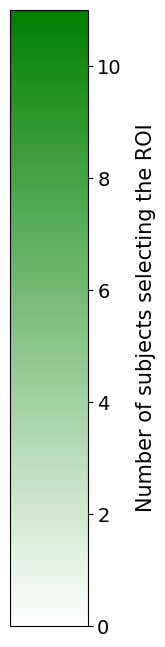

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colorbar import ColorbarBase
savepathIMG = "../Images/Paper/Brain/Region_selection_criteria/"
cmap = LinearSegmentedColormap.from_list("white_to_green", ["white", "green"])
norm = Normalize(vmin=0, vmax=11)
fig, ax = plt.subplots(figsize=(1, 8))  # tall figure for vertical colorbar
cb = ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', label='Number of subjects selecting the ROI')
cb.ax.yaxis.label.set_size(15); cb.ax.tick_params(labelsize=14)
cb.ax.yaxis.labelpad=10
plt.savefig(f"{savepathIMG}colorbar_alldata_perfold_MEG_EEG_max11sbj.png", dpi=300, bbox_inches='tight')

# Windowizing procedure - Oerlap schematization


2026-07-21 11:57:11.072281: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-21 11:57:11.137932: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-21 11:57:12.465115: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


subject_1 trial_94 has wrong shape ((2,))
subject_1 trial_95 has wrong shape ((2,))
subject_1 trial_94 has wrong shape ((2,))
subject_1 trial_95 has wrong shape ((2,))


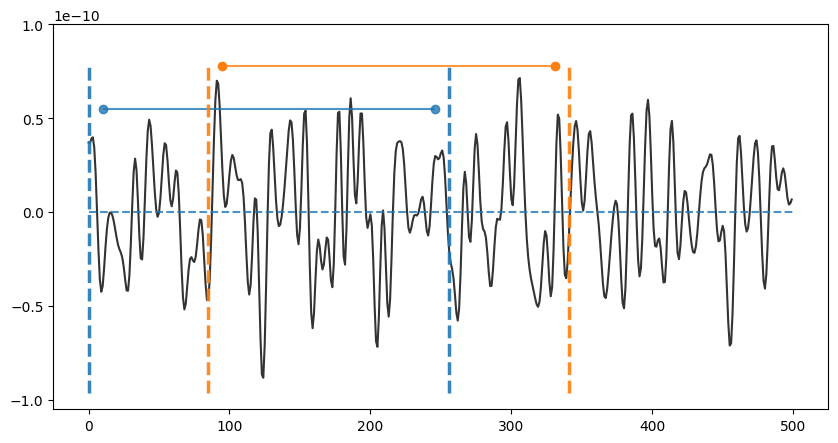

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import read_subject


data_folder="../Data/"


subject_index = 1

data_2_MI = read_subject(data_folder, "EEG", "MI",subject_index)
data_2_Rest = read_subject(data_folder, "EEG", "Baseline",subject_index)

# My frequency sampling
sfreq = 250

from scipy.signal import firwin, filtfilt
figname="../Images/Paper/Windowing_example.png"

signal = data_2_MI[1][19]
numtaps = 501
fs = 250 
fir = firwin(numtaps, [4, 35], pass_zero=False, fs=fs)
filtered = filtfilt(fir, 1.0,signal )

shift = 200
amplitude_tot = 500 

T = 256
shift = 85
hline_shift = 10
hls = hline_shift

fg,ax =plt.subplots(figsize=(10,5))
ax.plot(filtered[shift:amplitude_tot+shift],color="black",alpha=0.8)
ymin,ymax = np.array(ax.get_ylim())#*1.1
plt.hlines(0,0,amplitude_tot,linestyles="--", alpha = 0.8)

plt.vlines([0,T],ymin,ymax , linestyles="--", alpha = 0.9, linewidth=2.5)
plt.hlines(0.55*10**(-10),hls ,T-hls, alpha = 0.8)
plt.scatter([hls ,T-hls],[0.55*10**(-10)]*2, alpha = 0.8)

plt.vlines([0+shift,T+shift],ymin,ymax, linestyles="--", alpha = 0.9, color = "C1" , linewidth=2.5,zorder=4)
plt.hlines([0.78*10**(-10)],hls+shift,T-hls+shift, alpha = 0.8,color="C1")
plt.scatter([hls+shift ,T-hls+shift],[0.78*10**(-10)]*2,zorder=3,color="C1")

ticks = plt.yticks(np.arange(-1,1.5,0.5)*10**(-10))
plt.savefig(figname, dpi=300, bbox_inches='tight')
# plt.vlines([0+2*shift,T+2*shift],ymin,ymax, linestyles="--", alpha = 0.9, color = "C2" , linewidth=2.5,zorder=4)
# plt.hlines([0.98*10**(-10)],hls+2*shift,T-hls+2*shift, alpha = 0.8,color="C2")
# plt.scatter([hls+2*shift ,T-hls+2*shift],[0.98*10**(-10)]*2,zorder=3,color="C2")